In [8]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("../results/figures", exist_ok=True)

In [7]:
df = pd.read_csv("../data/raw/EThOS_CSV_202310.csv", 
                 low_memory=False, 
                 encoding='latin-1')

df.to_parquet("../data/raw/ethos.parquet")
print(f"Total records: {len(df):,}")
print(f"\nColumns: {df.columns.tolist()}")

Total records: 639,252

Columns: ['Title', 'DOI', 'Author', 'Author ISNI', 'ORCID', 'Institution', 'Institution ISNI', 'Date', 'Qualification', 'Abstract', 'Subject Discipline', 'Supervisor(s)', 'Funder(s)', 'EThOS URL', 'IR URL']


In [9]:
has_abstract = df['Abstract'].str.strip().replace('', None).notna().sum()
total = len(df)
print(f"Records WITH abstracts:    {has_abstract:,}")
print(f"Records WITHOUT abstracts: {total - has_abstract:,}")
print(f"Abstract coverage:         {has_abstract/total*100:.1f}%")

Records WITH abstracts:    390,200
Records WITHOUT abstracts: 249,052
Abstract coverage:         61.0%


In [11]:
# First check what the Date column actually looks like
print(df['Date'].dtype)
print(df['Date'].head(10))

object
0    1989
1    1983
2    1983
3    1984
4    1985
5    1985
6    1985
7    1985
8    1986
9    1986
Name: Date, dtype: object


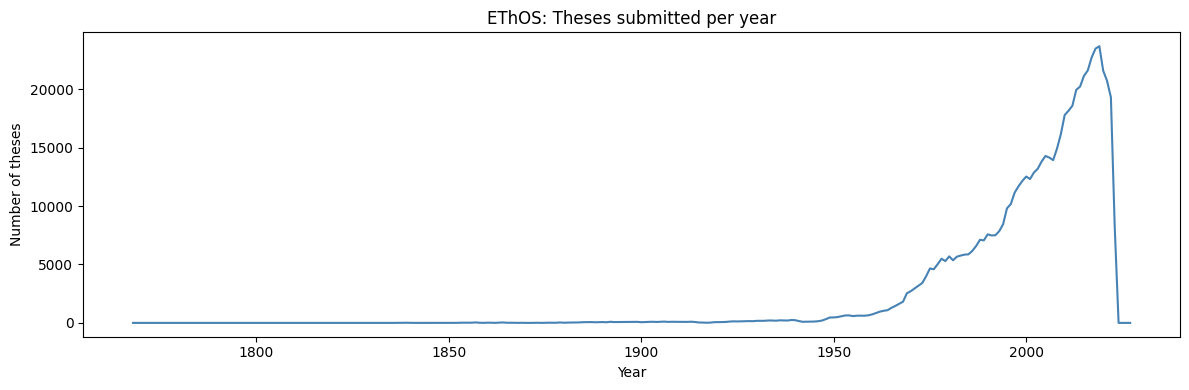

Saved.


In [12]:
df['Year'] = pd.to_numeric(df['Date'], errors='coerce')

df['Year'].value_counts().sort_index().plot(
    kind='line',
    figsize=(12, 4),
    title="EThOS: Theses submitted per year",
    color='steelblue'
)
plt.xlabel("Year")
plt.ylabel("Number of theses")
plt.tight_layout()
plt.savefig("../results/figures/ethos_by_year.png", dpi=150)
plt.show()
print("Saved.")

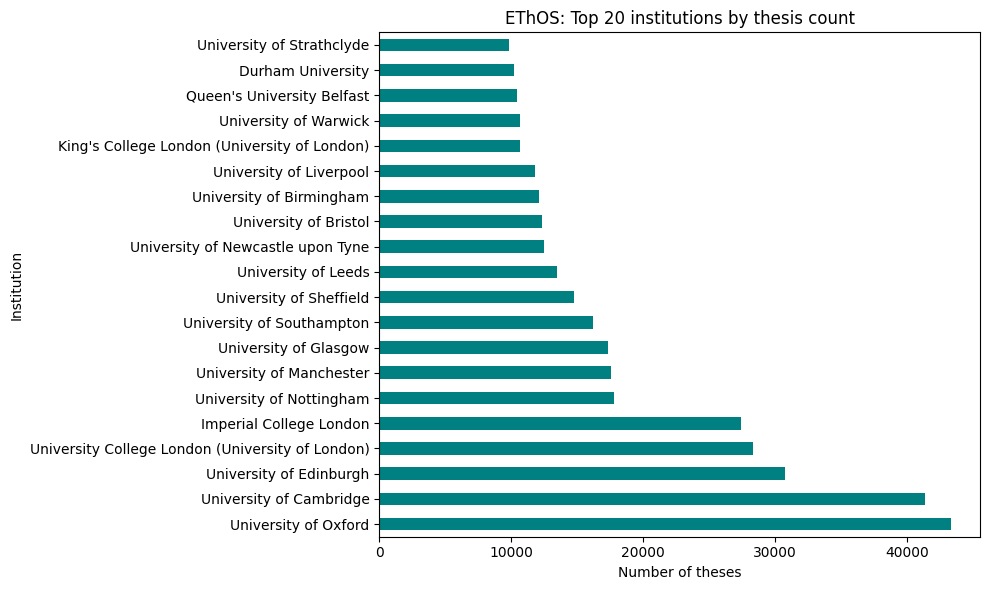

Saved.


In [13]:
df['Institution'].value_counts().head(20).plot(
    kind='barh',
    figsize=(10, 6),
    title="EThOS: Top 20 institutions by thesis count",
    color='teal'
)
plt.xlabel("Number of theses")
plt.tight_layout()
plt.savefig("../results/figures/ethos_institutions.png", dpi=150)
plt.show()
print("Saved.")